|<img src="https://www.udp.cl/cms/wp-content/uploads/2021/06/UDP_LogoRGB_2lineas_Color_SinFondo.png" width="500" height="100">| <p> Ciencias de Datos para la Economía</p>  <p> Ingeniería Comercial </p><p> Profesor: Luis Cuevas Parra </p><p>Unidad 2: Introducción a Python para el Análisis Económico</p><p> Intro a Series de Tiempo </p>|
|---|---|

# Descomposición, Estacionariedad, Suavizado y AR-MA

Para abordar esta tem'atica, utilizaremos datos del PIB y la tasa de desempleo de Chile, obtenidos desde la
API pública del Banco Mundial (`api.worldbank.org`).

## ¿Por qué modelar series de tiempo económicas?

El PIB y el desempleo son series con tres propiedades que las distinguen de datos de
corte transversal:

1. **Tendencia:** el nivel de la economía crece en el largo plazo (crecimiento potencial).
2. **Ciclo:** hay expansiones y recesiones que se apartan de esa tendencia por varios años.
3. **Persistencia:** el valor de este año predice, en algún grado, el del próximo. Las variables macro tienen "memoria".

> **Consecuencia:** OLS estándar falla porque los residuos quedan autocorrelacionados.
> Necesitamos modelos que capturen explícitamente esa dependencia temporal.

In [1]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import itertools
import warnings

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

# Paleta de colores del curso (misma que Sm9 / Sm9a)
COLOR_PIB    = '#800020'   # serie principal
COLOR_TREND  = '#1f77b4'   # tendencia / componente ajustado
COLOR_OK     = '#2ca02c'   # pronóstico / lectura favorable
COLOR_GRAY   = '#7f7f7f'   # observado en test / residuo
COLOR_ALT    = '#ff7f0e'   # método alternativo de suavizado
COLOR_ALERT  = '#d62728'   # serie de contraste (desempleo)

## 1. Importación de Datos: Obtener las series desde la API del Banco Mundial

La API del Banco Mundial no requiere credenciales: se consulta
`api.worldbank.org/v2/country/{pais}/indicator/{indicador}` y devuelve JSON con una observación **anual** por año disponible.

Tres series de Chile (código ISO3 `CHL`):

| Indicador | Código | Naturaleza |
|-----------|--------|-----------------------|
| PIB real (US\$ constantes de 2015) | `NY.GDP.MKTP.KD` | Serie **en nivel** |
| Crecimiento del PIB (variación % anual) | `NY.GDP.MKTP.KD.ZG` | Serie **transformada**|
| Tasa de desempleo (% de la fuerza laboral) | `SL.UEM.TOTL.ZS` | Serie de **contraste** |

In [2]:
def wb_serie(indicador: str, pais: str = 'CHL', nombre: str | None = None) -> pd.Series:
    """Descarga una serie anual desde la API pública del Banco Mundial (sin credenciales)."""
    url = f'https://api.worldbank.org/v2/country/{pais}/indicator/{indicador}'
    r = requests.get(url, params={'format': 'json', 'per_page': 20000}, timeout=30)
    r.raise_for_status()
    _, obs = r.json()
    df = pd.DataFrame(obs)
    df = df.assign(anio=pd.to_numeric(df['date']), valor=pd.to_numeric(df['value']))
    df = df.dropna(subset=['valor']).sort_values('anio').reset_index(drop=True)
    indice = pd.to_datetime(df['anio'].astype(int).astype(str) + '-01-01')
    return pd.Series(df['valor'].values, index=indice, name=nombre or indicador).asfreq('YS')

In [3]:
series_dic ={'NY.GDP.MKTP.KD':'PIB nivel',
'NY.GDP.MKTP.KD.ZG': 'Crecimiento PIB',
'SL.UEM.TOTL.ZS':'Desempleo'}

In [4]:
df_wb = pd.DataFrame()

for clave, valor in series_dic.items():
    df_wb[valor] = wb_serie(clave)


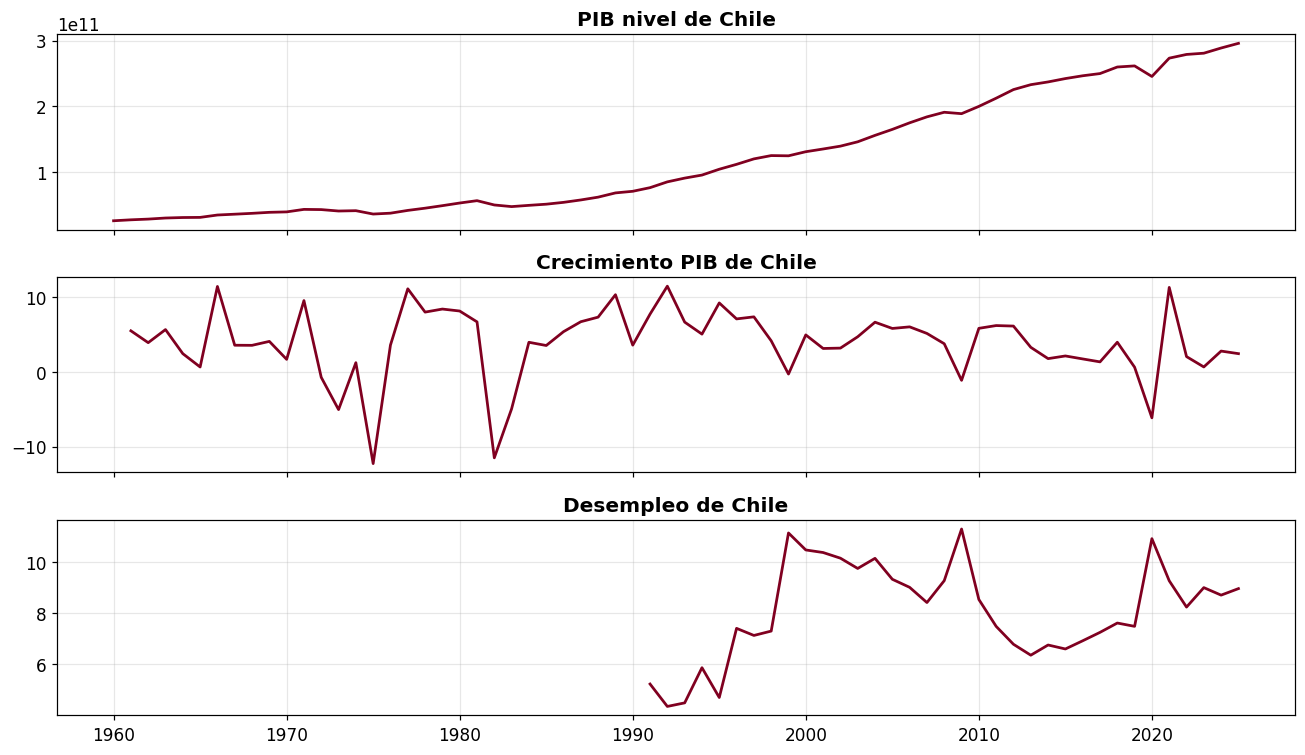

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

for i, col in enumerate(df_wb.columns):
    
    axes[i].plot(df_wb.index, df_wb[col], color=COLOR_PIB, lw=1.8)
    axes[i].set_title(f'{col} de Chile', fontweight='bold')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 2. Descomposición: tendencia-ciclo en datos anuales

La descomposición clásica separa una serie en $Y_t = T_t + S_t + R_t$ (tendencia,
estacionalidad, residuo). Con datos **anuales** no hay un patrón que se repita
dentro del año, así que $S_t$ no está definida: la descomposición estacional
necesita frecuencia mensual o trimestral.

Lo que sí podemos extraer de una serie anual es la **tendencia-ciclo** $T_t$: una
media móvil centrada que suaviza el ruido de corto plazo y deja ver el ciclo
económico. El residuo $R_t = Y_t - T_t$ debería concentrar los años de crisis y de auge.


In [7]:
pib_nivel = df_wb['PIB nivel']

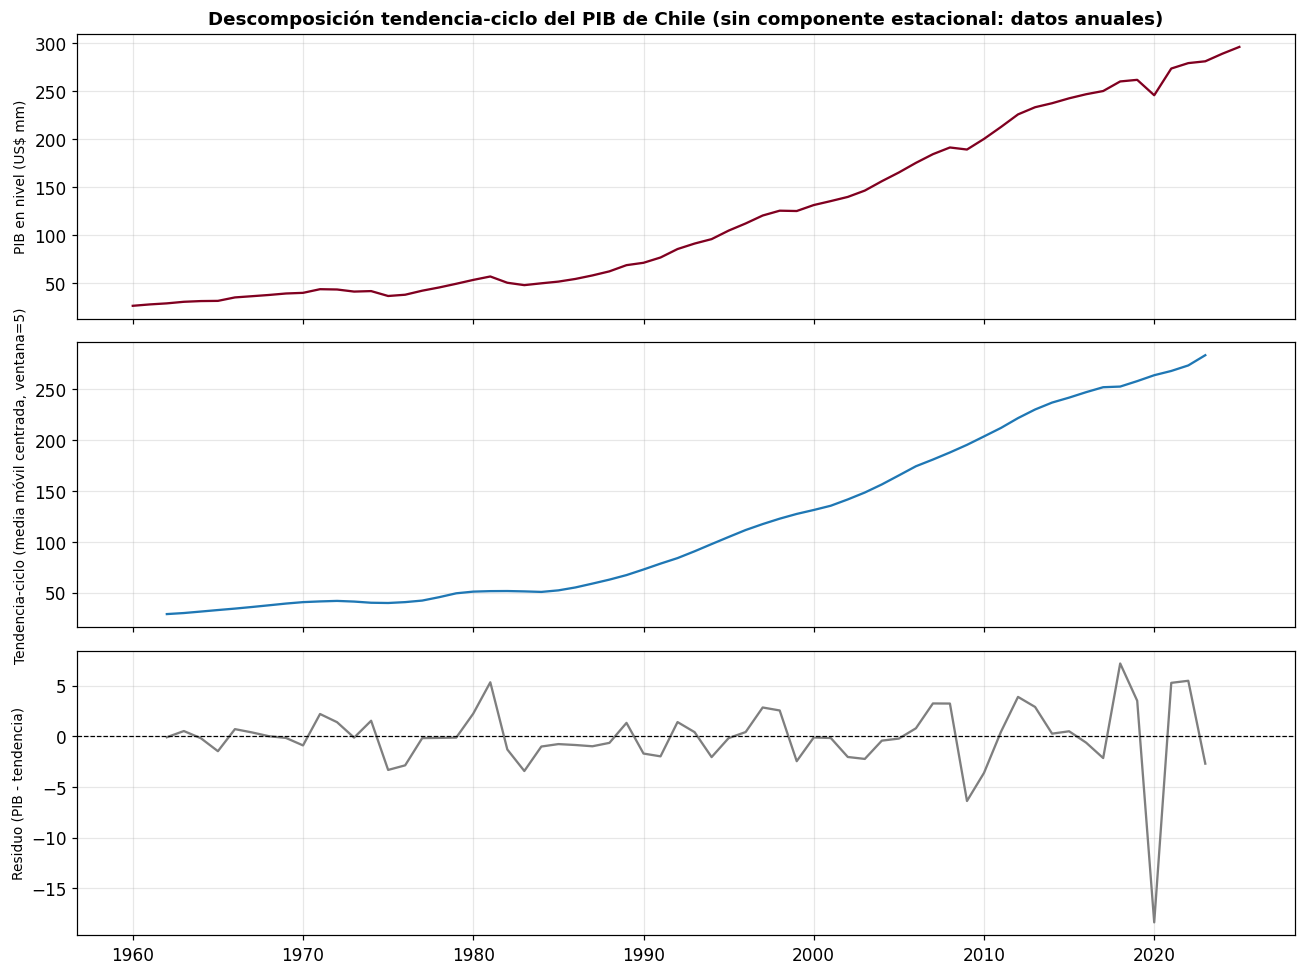

In [8]:
# Ventana movil
tendencia = pib_nivel.rolling(window=5, center=True).mean()

# Diferencia entre pib observado y media movil
residuo = pib_nivel - tendencia

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
paneles = [
    (pib_nivel / 1e9,  'PIB en nivel (US$ mm)', COLOR_PIB),
    (tendencia / 1e9,  'Tendencia-ciclo (media móvil centrada, ventana=5)', COLOR_TREND),
    (residuo / 1e9,    'Residuo (PIB - tendencia)', COLOR_GRAY),
]
for ax, (data, titulo, color) in zip(axes, paneles):
    ax.plot(data.index, data.values, color=color, lw=1.5)
    ax.set_ylabel(titulo, fontsize=9)
    ax.grid(True, alpha=0.3)
axes[2].axhline(0, color='black', lw=0.8, linestyle='--')
axes[0].set_title('Descomposición tendencia-ciclo del PIB de Chile (sin componente estacional: datos anuales)',
                   fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [9]:
peores_anios = (residuo.dropna() / 1e9).sort_values().head(6)
print("Años con el residuo más negativo (mayor caída respecto de la tendencia-ciclo):")
print(peores_anios.round(2).to_string())

Años con el residuo más negativo (mayor caída respecto de la tendencia-ciclo):
anio
2020-01-01   -18.36
2009-01-01    -6.38
2010-01-01    -3.60
1983-01-01    -3.42
1975-01-01    -3.31
1976-01-01    -2.86


> Estos años coinciden con episodios de crisis reconocidos de la economía chilena: 
> - el shock del petróleo y el ajuste de 1975
> - la crisis de la deuda de 1982-83
> - la crisis financiera global de 2009
> - la caída de actividad por la pandemia en 2020. 
> 
> El residuo de una descomposición captura eso: el ciclo, no el ruido.

## 3. Estacionariedad

Una serie es **estacionaria (débilmente)** si:
1. $\mathbb{E}[Y_t] = \mu$ constante para todo $t$.
2. $\text{Var}(Y_t) = \sigma^2 < \infty$ constante para todo $t$.
3. $\text{Cov}(Y_t, Y_{t-k}) = \gamma_k$ depende solo del rezago $k$, no de $t$.

### 3.1 Prueba intuitiva: comparar mitades

Si se corta la serie en dos mitades y las medias son muy distintas, no es estacionaria.

In [10]:
pib_crec = df_wb['Crecimiento PIB'].dropna()
desempleo = df_wb['Desempleo'].dropna()


In [11]:
def comparar_mitades(serie: pd.Series, nombre: str) -> None:
    h = len(serie) // 2
    primera, segunda = serie.iloc[:h], serie.iloc[h:]
    print(f"{nombre}:")
    print(f"  Media 1a mitad = {primera.mean():,.2f}   Media 2a mitad = {segunda.mean():,.2f}")
    print(f"  Var  1a mitad = {primera.var():,.2f}   Var  2a mitad = {segunda.var():,.2f}")
    print()

comparar_mitades(pib_nivel, "PIB en nivel")
comparar_mitades(pib_crec, "Crecimiento del PIB")

PIB en nivel:
  Media 1a mitad = 46,351,350,048.27   Media 2a mitad = 194,607,121,715.60
  Var  1a mitad = 207,503,615,067,735,654,400.00   Var  2a mitad = 4,074,627,757,798,093,488,128.00

Crecimiento del PIB:
  Media 1a mitad = 3.92   Media 2a mitad = 3.89
  Var  1a mitad = 33.91   Var  2a mitad = 10.64



- La media del PIB en nivel se multiplica por ~4 entre mitades -> NO estacionaria.

- La media del crecimiento del PIB es casi idéntica entre mitades (~3.9% vs ~3.9%) -> candidata a estacionaria.

- La varianza del crecimiento SI cae entre mitades (economia mas volatil antes de 2000: shocks del petroleo, crisis de la deuda, hiperinflacion relativa. Por lo tanto, existe estacionariedad en media, con matices en varianza.

### 3.2 Test de Dickey-Fuller Aumentado (ADF)

El **test ADF** determina formalmente si una serie tiene raíz unitaria:
- $H_0$: raíz unitaria — serie **no estacionaria**.
- $H_1$: serie **estacionaria**.
- Si $p < 0.05$ → se rechaza $H_0$ → estacionaria.

In [12]:
adfuller(pib_nivel.dropna(), autolag='AIC')

(np.float64(2.8313341597873802),
 1.0,
 0,
 65,
 {'1%': np.float64(-3.5352168748293127),
  '5%': np.float64(-2.9071540828402367),
  '10%': np.float64(-2.5911025443786984)},
 np.float64(2581.952886252621))

In [23]:
def test_adf(serie: pd.Series, nombre: str) -> None:
    resultado = adfuller(serie.dropna(), autolag='AIC')
    print(f"{'=' * 45}")
    print(f"Test ADF: {nombre}")
    print(f"{'=' * 45}")
    print(f"  Estadístico ADF : {resultado[0]:.4f}")
    print(f"  p-value         : {resultado[1]:.4f}")
    print(f"  Rezagos usados  : {resultado[2]}")
    print(f"  N observaciones : {resultado[3]}")
    for clave, val in resultado[4].items():
        print(f"  Valor crítico {clave}: {val:.4f}")
    if resultado[1] < 0.05:
        print("  -> ESTACIONARIA (rechaza H0)")
    else:
        print("  -> NO ESTACIONARIA (no rechaza H0)")
    print()

test_adf(pib_nivel, "PIB en nivel")
test_adf(pib_crec, "Crecimiento del PIB")
test_adf(desempleo, "Tasa de desempleo")

Test ADF: PIB en nivel
  Estadístico ADF : 2.8313
  p-value         : 1.0000
  Rezagos usados  : 0
  N observaciones : 65
  Valor crítico 1%: -3.5352
  Valor crítico 5%: -2.9072
  Valor crítico 10%: -2.5911
  -> NO ESTACIONARIA (no rechaza H0)

Test ADF: Crecimiento del PIB
  Estadístico ADF : -6.2433
  p-value         : 0.0000
  Rezagos usados  : 0
  N observaciones : 64
  Valor crítico 1%: -3.5369
  Valor crítico 5%: -2.9079
  Valor crítico 10%: -2.5915
  -> ESTACIONARIA (rechaza H0)

Test ADF: Tasa de desempleo
  Estadístico ADF : -2.4118
  p-value         : 0.1384
  Rezagos usados  : 0
  N observaciones : 34
  Valor crítico 1%: -3.6392
  Valor crítico 5%: -2.9512
  Valor crítico 10%: -2.6144
  -> NO ESTACIONARIA (no rechaza H0)



El PIB en nivel no rechaza $H_0$ (como se esperaba: tendencia clara). El crecimiento del PIB sí la rechaza con holgura. La tasa de desempleo queda en un punto intermedio:

El test **no** rechaza $H_0$ al 5%. Es una serie mucho más persistente que el crecimiento del PIB, aunque no tan claramente no-estacionaria como el PIB en nivel. Esto es exactamente el tipo de matiz que un test formal aporta sobre la intuición visual.

### 3.3 ACF y PACF — cuantificar la memoria temporal

La ACF y la PACF permiten ver **cuánta** memoria tiene una serie y son la base para
identificar el orden de un modelo AR-MA.

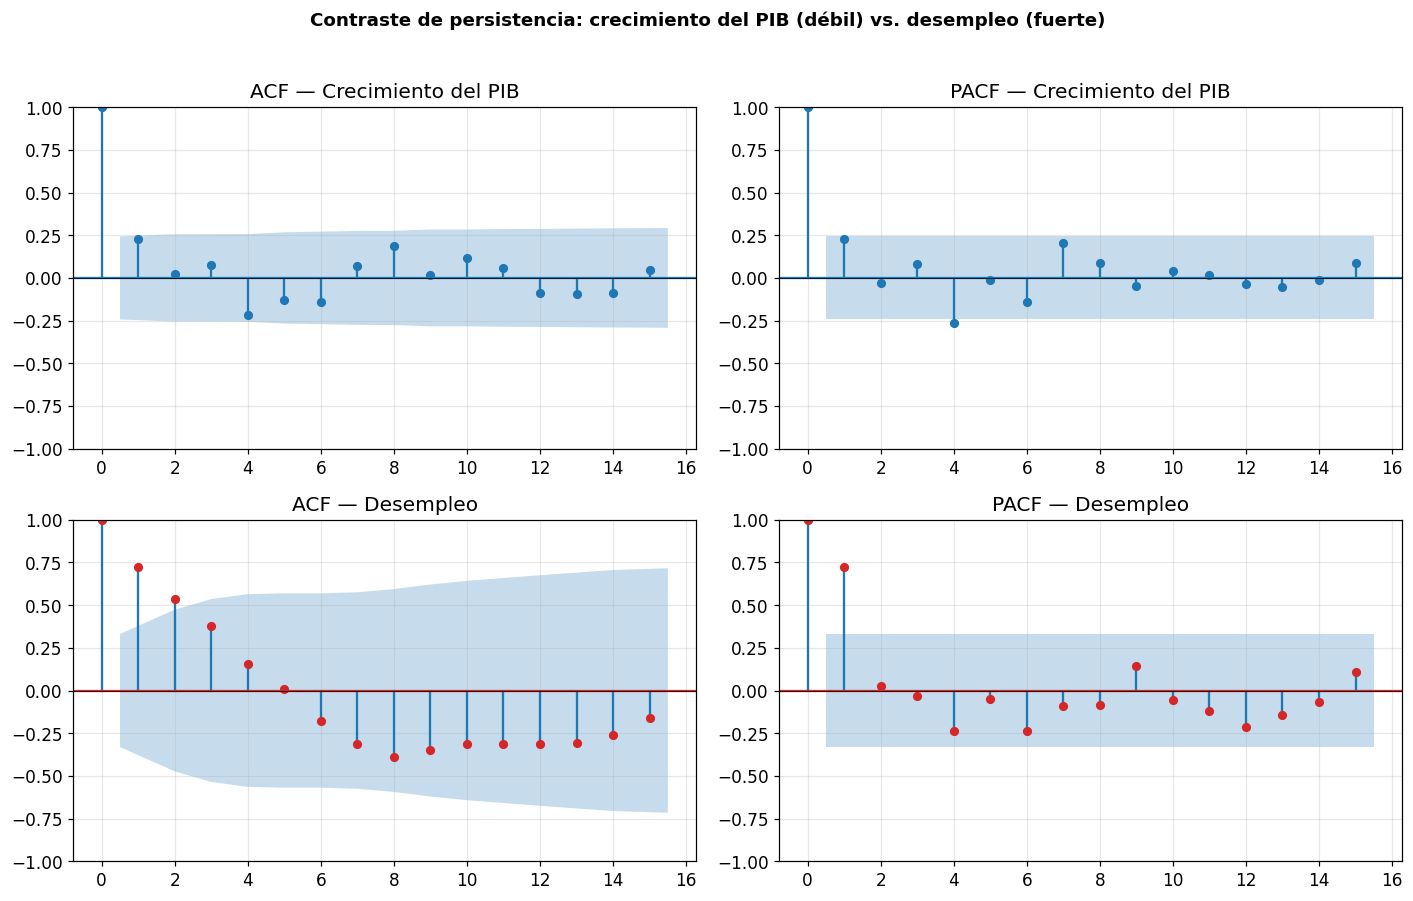

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

plot_acf(pib_crec, lags=15, ax=axes[0, 0], color=COLOR_TREND, title='ACF — Crecimiento del PIB')
plot_pacf(pib_crec, lags=15, ax=axes[0, 1], color=COLOR_TREND, method='ywm', title='PACF — Crecimiento del PIB')
plot_acf(desempleo.dropna(), lags=15, ax=axes[1, 0], color=COLOR_ALERT, title='ACF — Desempleo')
plot_pacf(desempleo.dropna(), lags=15, ax=axes[1, 1], color=COLOR_ALERT, method='ywm', title='PACF — Desempleo')

for ax in axes.ravel():
    ax.grid(True, alpha=0.3); ax.axhline(0, color='black', lw=0.5)

plt.suptitle('Contraste de persistencia: crecimiento del PIB (débil) vs. desempleo (fuerte)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

- Crecimiento del PIB: ACF/PACF en lag 1 ~0.23-0.31, caen rápido dentro de la banda -> memoria corta, poca persistencia.
- Desempleo: ACF decae lento (lag1 ~0.72) y PACF corta fuerte en lag 1 (~0.72), con alta persistencia, coherente con no rechazar el ADF.

## 4. Suavizado

A diferencia de la media móvil **centrada** de la sección anterior (que usa
observaciones futuras y solo sirve para describir el pasado), el suavizado para
pronóstico solo puede usar información **hasta el momento presente**. Por eso las
medias móviles y el suavizado exponencial aquí son de ventana **rezagada**
(trailing), no centrada.

Separamos el crecimiento del PIB en entrenamiento (hasta 2017) y prueba (2018-2025,
8 años) para poder comparar métodos de forma honesta, igual que exige el programa del
curso ("evaluación rigurosa de pronósticos... comparación contra benchmark ingenuo").

In [42]:
train, test = pib_crec.iloc[:-8], pib_crec.iloc[-8:]
print(f"Entrenamiento: {train.index.year.min()}-{train.index.year.max()}  (n={len(train)})")
print(f"Prueba       : {test.index.year.min()}-{test.index.year.max()}  (n={len(test)})")

benchmark_media = train.mean()
print(f"\nBenchmark ingenuo (media histórica de entrenamiento): {benchmark_media:.3f}%")

Entrenamiento: 1961-2017  (n=57)
Prueba       : 2018-2025  (n=8)

Benchmark ingenuo (media histórica de entrenamiento): 4.138%


> Nota: para una serie que oscila en torno a una media (no una caminata aleatoria), el benchmark relevante es la **MEDIA histórica**, no el último valor repetido

## Media Móvil Simple (SMA - Simple Moving Average)

La Media Móvil Simple calcula el promedio aritmético de las últimas $k$ observaciones dentro de una ventana temporal fija que se desplaza en el tiempo:$$SMA_t = \frac{1}{k} \sum_{i=0}^{k-1} x_{t-i}$$Cada dato dentro de la ventana recibe exactamente el mismo peso ($1/k$), y los datos anteriores al período $t - k + 1$ se excluyen por completo.

**Ventajas**:
- Interpretabilidad directa: Es intuitiva y fácil de explicar a audiencias no técnicas.
- Simplicidad computacional: Su cálculo y verificación manual son inmediatos.
- Suavizamiento efectivo: Elimina con facilidad el ruido blanco de alta frecuencia en series estables.

**Desventajas**:
- Efecto rezago (lag): Reacciona con retraso ante quiebres estructurales o cambios bruscos de tendencia.
- Sensibilidad a valores atípicos y efecto acantilado: Un dato extremo afecta al promedio durante toda la ventana $k$, y al salir de ella genera un salto artificial en la serie (drop-off effect).
- Ponderación uniforme: Asume de forma poco realista que una observación de hace 30 períodos tiene la misma relevancia que la de ayer.

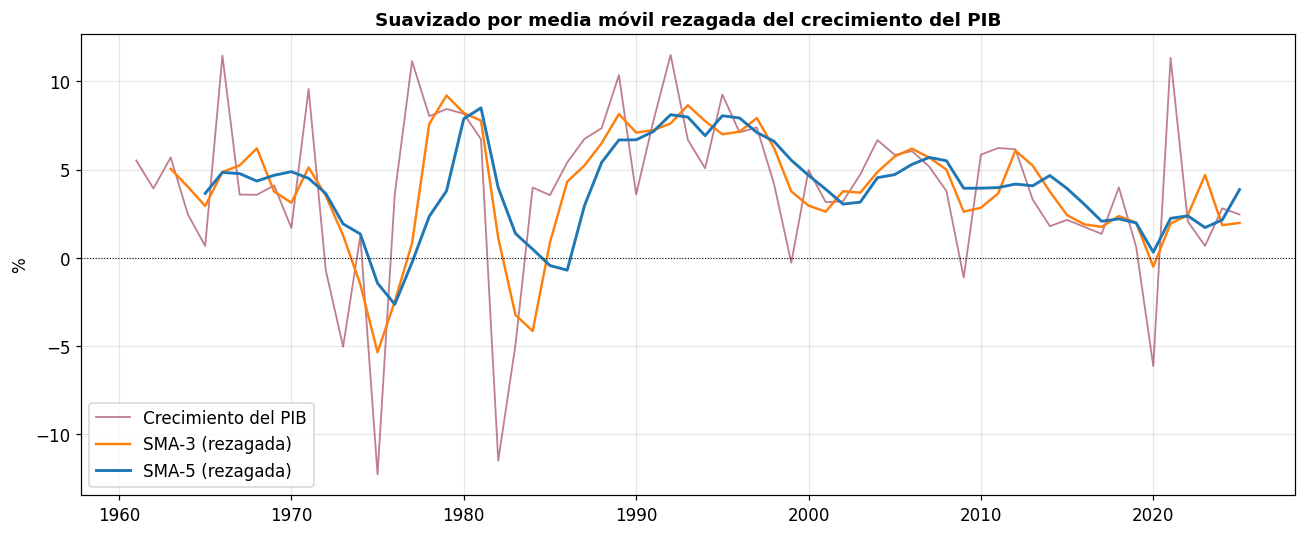

In [43]:
sma3 = pib_crec.rolling(window=3).mean()
sma5 = pib_crec.rolling(window=5).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pib_crec.index, pib_crec.values, color=COLOR_PIB, lw=1.2, alpha=0.5, label='Crecimiento del PIB')
ax.plot(sma3.index, sma3.values, color=COLOR_ALT, lw=1.6, label='SMA-3 (rezagada)')
ax.plot(sma5.index, sma5.values, color=COLOR_TREND, lw=1.9, label='SMA-5 (rezagada)')
ax.axhline(0, color='black', lw=0.7, linestyle=':')
ax.set_title('Suavizado por media móvil rezagada del crecimiento del PIB', fontsize=12, fontweight='bold')
ax.set_ylabel('%'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Media Móvil Ponderada Exponencialmente (EWMA / EWM)

La Media Móvil Ponderada Exponencialmente asigna ponderaciones decrecientes de forma exponencial a las observaciones pasadas, dando el mayor peso a la información más reciente:$$EWM_t = \alpha x_t + (1 - \alpha) EWM_{t-1}$$donde $\alpha \in (0, 1]$ es el factor de decaimiento o suavizamiento (a menudo parametrizado vía span o vida media: $\alpha = \frac{2}{s + 1}$). A diferencia de la SMA, la EWM incorpora teóricamente todo el historial de la serie con pesos asintóticamente cercanos a cero.

Ventajas:
- Menor rezago: Al priorizar los datos recientes, detecta giros de tendencia, aceleraciones o cambios de volatilidad mucho más rápido.
- Sin caídas abruptas: No sufre del efecto acantilado porque los datos antiguos pierden peso de forma gradual y suave en lugar de desaparecer súbitamente.
- Ajuste fino: Permite calibrar la sensibilidad de respuesta mediante un único parámetro continuo ($\alpha$, span o half-life).

Desventajas:
- Mayor sensibilidad al ruido puntual: Puede sobre-reaccionar a picos transitorios o anomalías en el dato más reciente si el valor de $\alpha$ es muy alto.
- Menor intuición conceptual: Requiere comprender el decaimiento exponencial y la calibración del parámetro $\alpha$.
- Sensibilidad a la inicialización: Las primeras observaciones de la serie dependen del valor semilla o método de arranque adoptado.

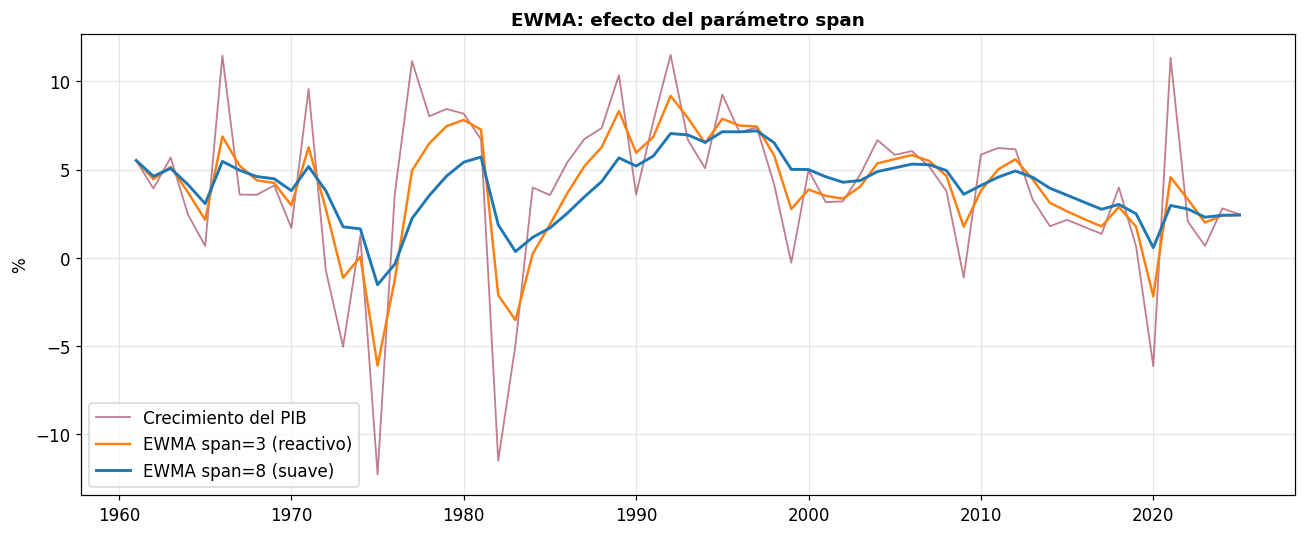

In [44]:
ewma_r = pib_crec.ewm(span=3).mean()
ewma_l = pib_crec.ewm(span=8).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pib_crec.index, pib_crec.values, color=COLOR_PIB, lw=1.2, alpha=0.5, label='Crecimiento del PIB')
ax.plot(ewma_r.index, ewma_r.values, color=COLOR_ALT, lw=1.6, label='EWMA span=3 (reactivo)')
ax.plot(ewma_l.index, ewma_l.values, color=COLOR_TREND, lw=1.9, label='EWMA span=8 (suave)')
ax.set_title('EWMA: efecto del parámetro span', fontsize=12, fontweight='bold')
ax.set_ylabel('%'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Suavizado exponencial como método de pronóstico: SES y Holt

**SES** pronostica solo el nivel: $\ell_t = \alpha y_t + (1-\alpha)\ell_{t-1}$.
**Holt** agrega tendencia: $\ell_t = \alpha y_t + (1-\alpha)(\ell_{t-1}+b_{t-1})$,
$b_t = \beta(\ell_t-\ell_{t-1}) + (1-\beta)b_{t-1}$.

**Holt-Winters** (nivel + tendencia + estacionalidad) no aplica aquí: requiere
`seasonal_periods` sub-anual. Para verlo en acción, con datos mensuales, revisa
`Sm9a-SeriesTemporales_Descripcion.ipynb`.

SES  — alpha óptimo: 0.0312
Holt — alpha: 0.0000  beta: 0.0000


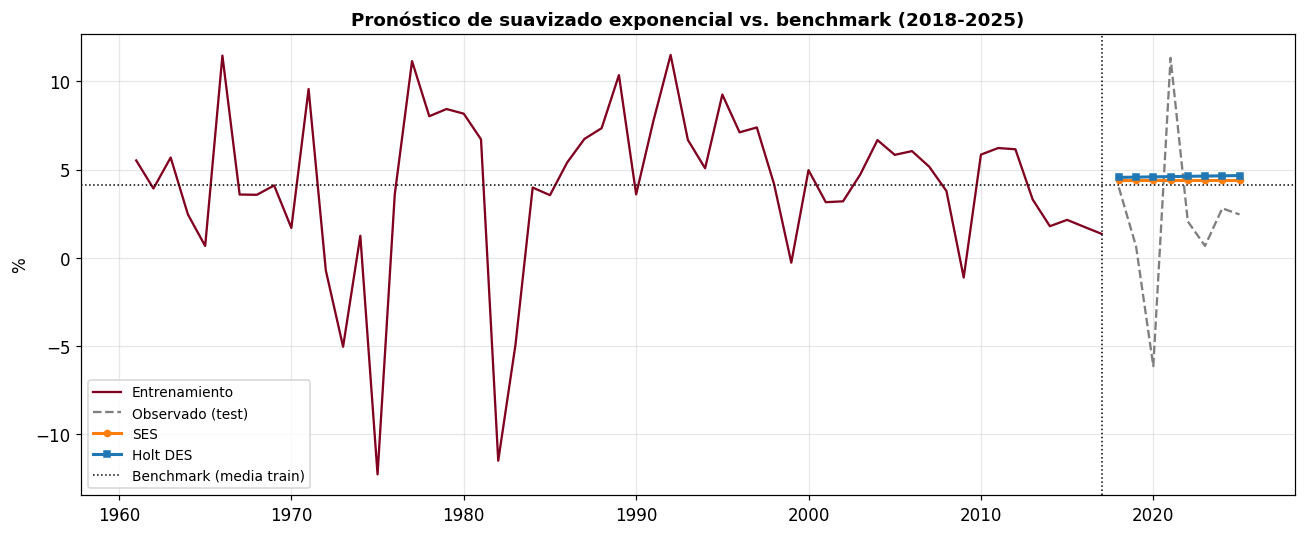

In [46]:
ses = SimpleExpSmoothing(train).fit(optimized=True)
fc_ses = ses.forecast(len(test))

holt = ExponentialSmoothing(train, trend='add').fit(optimized=True)
fc_holt = holt.forecast(len(test))

print(f"SES  — alpha óptimo: {ses.params['smoothing_level']:.4f}")
print(f"Holt — alpha: {holt.params['smoothing_level']:.4f}  beta: {holt.params['smoothing_trend']:.4f}")


fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train.index, train.values, color=COLOR_PIB, lw=1.5, label='Entrenamiento')
ax.plot(test.index, test.values, color=COLOR_GRAY, lw=1.5, linestyle='--', label='Observado (test)')
ax.plot(test.index, fc_ses.values, color=COLOR_ALT, lw=2, marker='o', markersize=4, label='SES')
ax.plot(test.index, fc_holt.values, color=COLOR_TREND, lw=2, marker='s', markersize=4, label='Holt DES')
ax.axhline(benchmark_media, color='black', lw=1, linestyle=':', label='Benchmark (media train)')
ax.axvline(train.index[-1], color='black', linestyle=':', lw=1)
ax.set_title('Pronóstico de suavizado exponencial vs. benchmark (2018-2025)', fontsize=12, fontweight='bold')
ax.set_ylabel('%'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Ambos $\alpha$ (y $\beta$) quedan cerca de cero: el optimizador encuentra que casi no conviene reaccionar a las últimas observaciones. Es coherente con una serie de memoria corta que oscila alrededor de una media, sin tendencia. Holt en particular colapsa a $\beta$=0 porque no hay tendencia real que estimar: es la herramienta equivocada para esta serie."

In [48]:
def errores(real: np.ndarray, pronostico, nombre: str) -> dict:
    pronostico = np.asarray(pronostico)
    mae = np.mean(np.abs(real - pronostico))
    rmse = np.sqrt(np.mean((real - pronostico) ** 2))
    return {'Método': nombre, 'MAE': round(mae, 3), 'RMSE': round(rmse, 3)}

comp_suavizado = pd.DataFrame([
    errores(test.values, fc_ses.values, 'SES'),
    errores(test.values, fc_holt.values, 'Holt DES'),
    errores(test.values, np.full(len(test), benchmark_media), 'Benchmark (media histórica)'),
])
print("Comparación de métodos de suavizado (período de prueba, 2018-2025):")
print(comp_suavizado.to_string(index=False))

Comparación de métodos de suavizado (período de prueba, 2018-2025):
                     Método   MAE  RMSE
                        SES 3.901 4.987
                   Holt DES 4.066 5.083
Benchmark (media histórica) 3.708 4.881


Ninguno de los dos métodos de suavizado le gana al benchmark ingenuo en este horizonte. Es un resultado honesto y esperable: el crecimiento del PIB tiene poca memoria de corto plazo, así que 'no reaccionar' (la media histórica) es difícil de vencer sin más información.

## 5. AR-MA

El modelo AR($p$) regresa $y_t$ sobre sus propios rezagos:
$$y_t = c + \phi_1 y_{t-1} + \cdots + \phi_p y_{t-p} + \varepsilon_t$$

El modelo MA($q$) expresa $y_t$ como función de choques pasados:
$$y_t = c + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}$$

ARMA($p,q$) combina ambos. Como el crecimiento del PIB ya es estacionario, se estima
directamente con `ARIMA(p, 0, q)`, sin diferenciar. Diferenciar series no
estacionarias ($d \geq 1$, Box-Jenkins completo, ARIMA/SARIMA) queda para más
adelante, ya visto en `Sm9-SeriesTemporales_ARIMA.ipynb` y `Sm10-SARIMA_ARIMAX.ipynb`.

In [52]:
resultados = []
for p, q in itertools.product(range(3), range(3)):
    if p == 0 and q == 0:
        continue
    modelo = ARIMA(train, order=(p, 0, q)).fit()
    resultados.append({'orden': f'ARMA({p},{q})', 'p': p, 'q': q,
                        'AIC': round(modelo.aic, 2), 'BIC': round(modelo.bic, 2)})

df_res = pd.DataFrame(resultados).sort_values('AIC').reset_index(drop=True)
print("Modelos AR-MA candidatos, ordenados por AIC:")
print(df_res.to_string(index=False))

mejor_aic = tuple(df_res.loc[df_res['AIC'].idxmin(), ['p', 'q']].astype(int))
mejor_bic = tuple(df_res.loc[df_res['BIC'].idxmin(), ['p', 'q']].astype(int))
print(f"\nMejor por AIC: ARMA{mejor_aic}   Mejor por BIC: ARMA{mejor_bic}")
    

Modelos AR-MA candidatos, ordenados por AIC:
    orden  p  q    AIC    BIC
ARMA(1,1)  1  1 334.95 343.12
ARMA(2,1)  2  1 335.67 345.89
ARMA(0,1)  0  1 335.84 341.97
ARMA(1,0)  1  0 336.42 342.55
ARMA(0,2)  0  2 337.20 345.37
ARMA(2,2)  2  2 337.76 350.02
ARMA(1,2)  1  2 337.93 348.14
ARMA(2,0)  2  0 338.24 346.41

Mejor por AIC: ARMA(1, 1)   Mejor por BIC: ARMA(0, 1)


AIC y BIC no coinciden, es normal. 
- AIC tiende a preferir modelos más ricos (mejor para pronóstico).
- BIC penaliza más los parámetros (más parsimonioso, mejor para inferencia). 

> Con diferencia de AIC menor a 2 entre los primeros candidatos, conviene mirar también parsimonia y diagnóstico de residuos.

In [58]:
ar1 = ARIMA(train, order=(1, 0, 0)).fit()
ma1 = ARIMA(train, order=(0, 0, 1)).fit()
arma11 = ARIMA(train, order=(1, 0, 1)).fit()

print("AR(1):")
print(f"  phi_1 = {ar1.params['ar.L1']:.4f}   AIC = {ar1.aic:.2f}")
print("MA(1):")
print(f"  theta_1 = {ma1.params['ma.L1']:.4f}   AIC = {ma1.aic:.2f}")
print("ARMA(1,1):")
print(f"  phi_1 = {arma11.params['ar.L1']:.4f}   theta_1 = {arma11.params['ma.L1']:.4f}   AIC = {arma11.aic:.2f}")


AR(1):
  phi_1 = 0.2949   AIC = 336.42
MA(1):
  theta_1 = 0.3528   AIC = 335.84
ARMA(1,1):
  phi_1 = -0.6425   theta_1 = 0.9998   AIC = 334.95


phi_1 ~ 0.30 en AR(1) es coherente con la PACF de la sección anterior (lag 1 ~0.23-0.31):
hay memoria de corto plazo, pero es débil. En ARMA(1,1), theta_1 queda muy cerca de 1,
una señal clásica de sobreparametrización (AR y MA casi se cancelan), otro argumento
para preferir el modelo más simple (AR(1) o MA(1)) por sobre ARMA(1,1) pese a su AIC.

### Diagnóstico de residuos

Un modelo bien especificado deja residuos que son **ruido blanco**: sin autocorrelación
(ACF/PACF dentro de las bandas) y sin estructura detectada por el test de Ljung-Box.

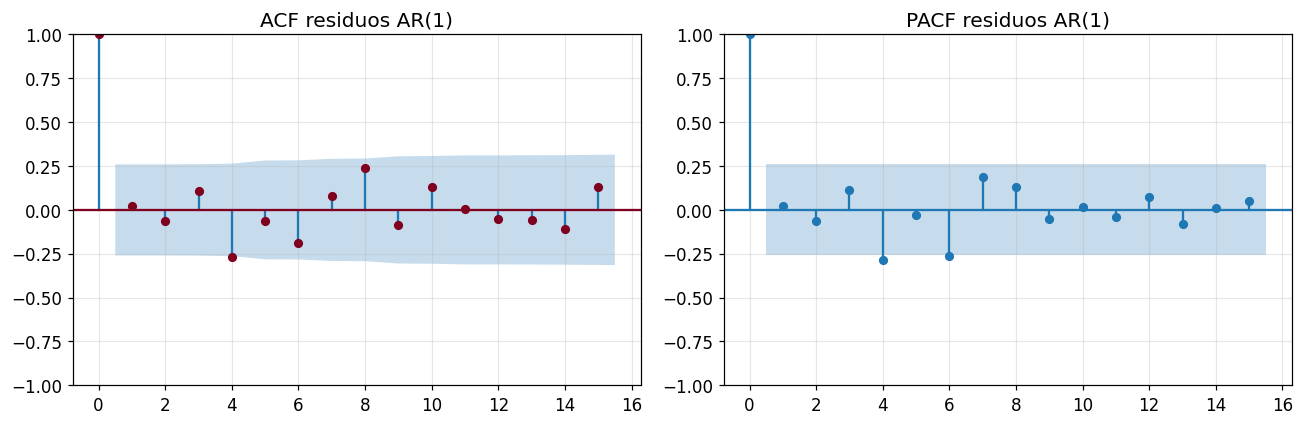

Test de Ljung-Box sobre los residuos del AR(1):
    lb_stat  lb_pvalue
5    5.8913     0.3169
10  14.3341     0.1583

-> p > 0.05 en todos los rezagos probados: residuos compatibles con ruido blanco.


In [54]:
modelo_final = ar1  # el más simple y más interpretable de los tres

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(modelo_final.resid, lags=15, ax=axes[0], color=COLOR_PIB, title='ACF residuos AR(1)')
plot_pacf(modelo_final.resid, lags=15, ax=axes[1], color=COLOR_TREND, method='ywm', title='PACF residuos AR(1)')
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

lb_test = acorr_ljungbox(modelo_final.resid, lags=[5, 10], return_df=True)
print("Test de Ljung-Box sobre los residuos del AR(1):")
print(lb_test.round(4).to_string())
if (lb_test['lb_pvalue'] > 0.05).all():
    print("\n-> p > 0.05 en todos los rezagos probados: residuos compatibles con ruido blanco.")
else:
    print("\n-> Hay estructura no capturada en algún rezago: reconsiderar la especificación.")

### Pronóstico fuera de muestra vs. benchmark ingenuo

La misma evaluación rigurosa que exige el programa del curso: separar entrenamiento y
prueba, y comparar contra un modelo de referencia antes de declarar que un modelo
"funciona".

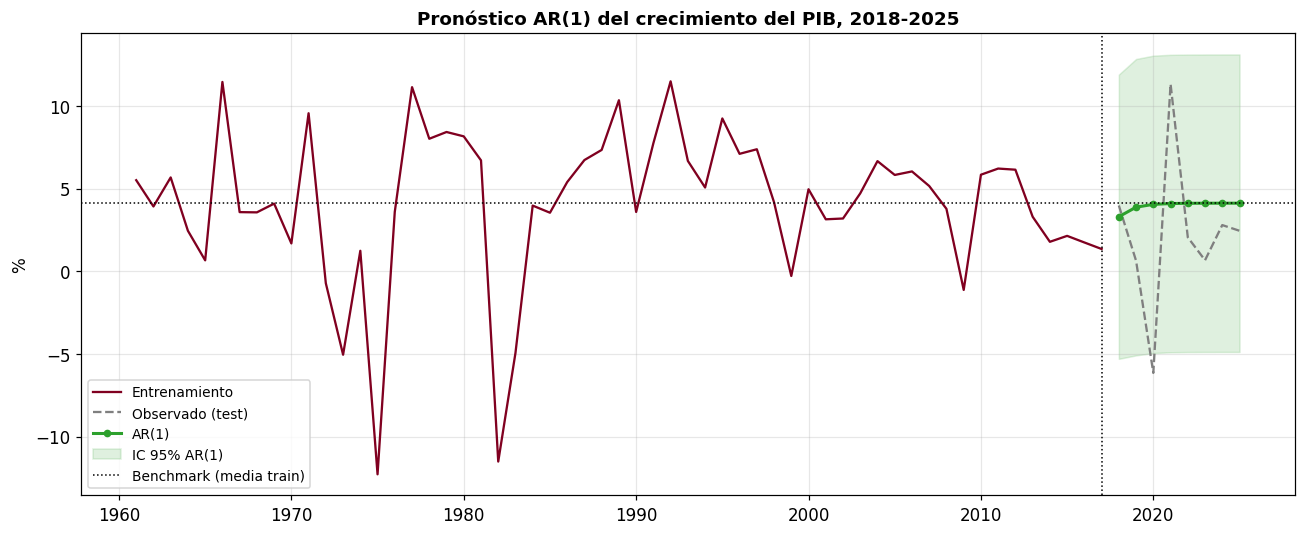

In [55]:
fc_ar1 = ar1.get_forecast(len(test))
pred_ar1 = fc_ar1.predicted_mean
ci_ar1 = fc_ar1.conf_int(alpha=0.05)

pred_ma1 = ma1.get_forecast(len(test)).predicted_mean
pred_arma11 = arma11.get_forecast(len(test)).predicted_mean

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train.index, train.values, color=COLOR_PIB, lw=1.5, label='Entrenamiento')
ax.plot(test.index, test.values, color=COLOR_GRAY, lw=1.5, linestyle='--', label='Observado (test)')
ax.plot(test.index, pred_ar1.values, color=COLOR_OK, lw=2, marker='o', markersize=4, label='AR(1)')
ax.fill_between(test.index, ci_ar1.iloc[:, 0], ci_ar1.iloc[:, 1], color=COLOR_OK, alpha=0.15, label='IC 95% AR(1)')
ax.axhline(benchmark_media, color='black', lw=1, linestyle=':', label='Benchmark (media train)')
ax.axvline(train.index[-1], color='black', linestyle=':', lw=1)
ax.set_title('Pronóstico AR(1) del crecimiento del PIB, 2018-2025', fontsize=12, fontweight='bold')
ax.set_ylabel('%'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [57]:
comp_final = pd.DataFrame([
    errores(test.values, pred_ar1.values, 'AR(1)'),
    errores(test.values, pred_ma1.values, 'MA(1)'),
    errores(test.values, pred_arma11.values, 'ARMA(1,1)'),
    errores(test.values, np.full(len(test), benchmark_media), 'Benchmark (media histórica)'),
    errores(test.values, fc_ses.values, 'SES (suavizado)'),
])
print("Comparación final, período de prueba 2018-2025:")
print(comp_final.to_string(index=False))

Comparación final, período de prueba 2018-2025:
                     Método   MAE  RMSE
                      AR(1) 3.731 4.846
                      MA(1) 3.763 4.884
                  ARMA(1,1) 3.895 4.744
Benchmark (media histórica) 3.708 4.881
            SES (suavizado) 3.901 4.987


Ningún modelo bate claramente al benchmark ingenuo en MAE; ARMA(1,1) tiene el mejor
RMSE, a costa de ser el modelo menos parsimonioso y con el theta_1 casi degenerado
visto arriba. Es una lección real, no un ejemplo de juguete: con solo memoria de
corto plazo débil, vencer sistemáticamente al benchmark ingenuo es difícil. Por eso
el programa del curso exige comparar siempre contra un modelo de referencia

## Resumen

### Diagrama de decisión


Serie y_t (anual)
    
    
1. Visualizar -> ¿tendencia? ¿ciclo? (sin estacionalidad: datos anuales)
    
    
2. Descomposición -> media móvil centrada -> tendencia-ciclo + residuo
                    (el residuo marca los años de crisis y auge)
    
3. Estacionariedad -> mitades + ADF + ACF/PACF
    - PIB en nivel      -> NO estacionaria (tendencia)
    - Crecimiento PIB   -> SI estacionaria (memoria corta)
    - Desempleo         -> persistente, no rechaza ADF al 5%
    │
    
4. Suavizado (solo información pasada: SMA/EWMA rezagada, SES, Holt)
                    -> ningún método le gana al benchmark ingenuo aquí
    
5. AR-MA -> ARIMA(p,0,q) sobre la serie ya estacionaria (sin diferenciar)
           -> grid search AIC/BIC, diagnóstico Ljung-Box, evaluación fuera de muestra
    
¿Y si la serie no fuera estacionaria? -> diferenciar (d>=1) -> ARIMA completo


### Reglas de identificación ACF / PACF

| Modelo | ACF | PACF |
|--------|-----|------|
| AR($p$) | Decae geométricamente | **Corta en lag $p$** |
| MA($q$) | **Corta en lag $q$** | Decae geométricamente |
| ARMA($p,q$) | Decae | Decae |


### Lecturas recomendadas

- Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice*
  (3ra ed.). OTexts. <https://otexts.com/fpp3/>
- Bianchi, F. M. *Time Series Analysis with Python* (handbook).
  <https://filippomb.github.io/python-time-series-handbook/>